In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import smote
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

In [2]:
df = pd.read_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Maze\cleaned_data.csv')

In [5]:
df.columns

Index(['user_id', 'monthly_income', 'monthly_expense_total', 'savings_rate',
       'budget_goal', 'financial_scenario', 'credit_score',
       'debt_to_income_ratio', 'loan_payment', 'investment_amount',
       'subscription_services', 'emergency_fund', 'transaction_count',
       'fraud_flag', 'discretionary_spending', 'essential_spending',
       'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status',
       'financial_advice_score', 'financial_stress_level', 'actual_savings',
       'savings_goal_met', 'year', 'month', 'expense_income_diff',
       'savings_delay_ratio', 'debt_duress'],
      dtype='object')

In [7]:
print(df['savings_goal_met'].value_counts())

savings_goal_met
0    2723
1     277
Name: count, dtype: int64


In [9]:
df.head(1)

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,...,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met,year,month,expense_income_diff,savings_delay_ratio,debt_duress
0,1584,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,689.22,...,2,8.3,Medium,0.0,0,2019,1,1.029648,3676.11,0.040316


In [11]:
df = df.drop(columns=['user_id', 'actual_savings', 'budget_goal', 'savings_rate','expense_income_diff','savings_delay_ratio','debt_duress'])

Dropping unecessary and leaky features from the dataset

In [47]:
df.head(1)

,monthly_income,monthly_expense_total,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,...,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,savings_goal_met,year,month
0,3119.58,3212.07,0,721.0,0.56,125.77,689.22,3,510.58,68,...,1910.85,0,1501.65,6,2,8.3,Medium,0,2019,1


In [49]:
X = df.drop(columns=['savings_goal_met'])
y = df['savings_goal_met']

categorical_col = X.select_dtypes(include=['object']).columns
numerical_col = X.select_dtypes(exclude=['object']).columns
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_col),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_col)
])

In [51]:
pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(n_estimators=200, learning_rate=0.05, scale_pos_weight = 10,max_depth=5,random_state=42,eval_metric='logloss'))
])

In [53]:
pipeline_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced'))
])

In [55]:
pipeline_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])

Pipeline Structure for XGB Classifier, Random Forest Classifier and Logistics Regression Completed!!
Pipeline was implemented to automate preprocessing and model training, ensuring consistency, scalability, and ease of deployment.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

In [61]:
pipeline_xgb.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy score: 0.945


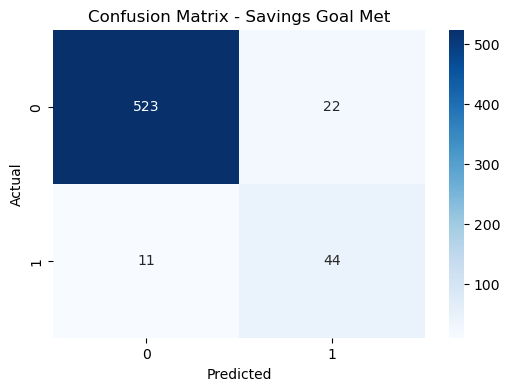

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       545
           1       0.67      0.80      0.73        55

    accuracy                           0.94       600
   macro avg       0.82      0.88      0.85       600
weighted avg       0.95      0.94      0.95       600



In [75]:
y_pred = pipeline_xgb.predict(X_test)
print('Accuracy score:', accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Savings Goal Met')
plt.show()
print(classification_report(y_test, y_pred))

In [65]:
pipeline_rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


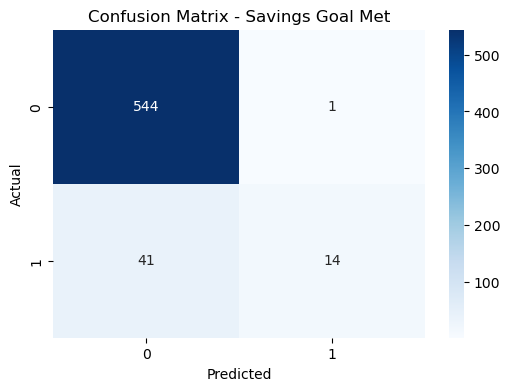

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       545
           1       0.93      0.25      0.40        55

    accuracy                           0.93       600
   macro avg       0.93      0.63      0.68       600
weighted avg       0.93      0.93      0.91       600

Accuracy Score 0.93


In [67]:
pred_rf = pipeline_rf.predict(X_test)
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Savings Goal Met')
plt.show()
print(classification_report(y_test, pred_rf))
print('Accuracy Score',accuracy_score(y_test, pred_rf))

In [69]:
pipeline_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


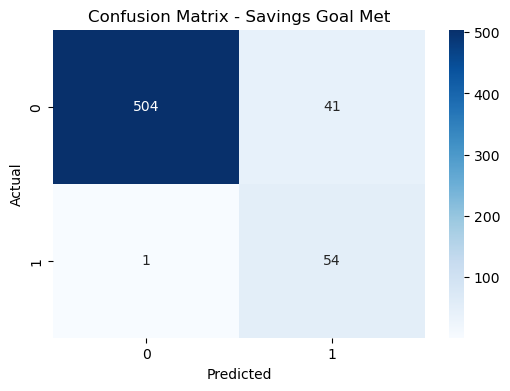

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       545
           1       0.57      0.98      0.72        55

    accuracy                           0.93       600
   macro avg       0.78      0.95      0.84       600
weighted avg       0.96      0.93      0.94       600

Accuracy Score 0.93


In [71]:
pred_lr = pipeline_lr.predict(X_test)
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Savings Goal Met')
plt.show()
print(classification_report(y_test, pred_lr))
print('Accuracy Score',accuracy_score(y_test, pred_lr))

### Model Evaluation

Three models were evaluated: Random Forest, Logistic Regression, and XGBoost. While all models achieved similar overall accuracy (93–94%), their performance differed significantly on the minority class.
Random Forest exhibited very high precision (0.93) but extremely low recall (0.25), indicating that it failed to identify most positive cases. Logistic Regression achieved near-perfect recall (0.98), successfully detecting almost all positive cases, but at the cost of low precision (0.57), leading to many false positives.

XGBoost provided the best balance, achieving a strong recall (0.80) while maintaining reasonable precision (0.67), resulting in the highest F1-score for the minority class. This makes XGBoost the most suitable model for real-world deployment, where both detection and reliability are important.

In [79]:
joblib.dump(pipeline_xgb, 'savings_goal_pkl')

['savings_goal_pkl']